# 01 — Policy Evaluation
**Week 4 | Dynamic Programming**

**Policy Evaluation** answers: *How good is a given policy π?*

We iteratively apply the Bellman expectation equation until V converges:

$$V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma V_k(s') \right]$$

In [13]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# ---- Reuse Grid World from Week 3 ----
class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size = size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits = {(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        """Return list of (prob, next_s, reward, done)."""
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:       return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:       return [(1.0, ns,  -5.0, True)]
        return [(1.0, ns, -0.1, False)]

env = GridWorld()

### IMPORTANT : Change made - V[s] to V[ns]

The	Bellman	expectation	equation	backs	up	the	value	of
the	successor	state.	With	the	bug,	each	state’s	value	feeds	back	into
itself	and	the	result	is	meaningless

In [14]:
def policy_evaluation(env, policy, gamma=0.99, theta=1e-6, max_iter=1000):
    """
    Iterative policy evaluation.
    policy: array of shape (n_states, n_actions) — action probabilities.
    Returns V: array of shape (n_states,)
    """
    V = np.zeros(env.n_states())
    history = [V.copy()]
    for iteration in range(max_iter):
        delta = 0.0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = 0.0
            for a in range(env.n_actions()):
                for prob, ns, reward, done in env.transitions(s, a):
                    v += policy[s, a] * prob * (reward + (0 if done else gamma * V[ns]))
            V_new[s] = v
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        history.append(V.copy())
        if delta < theta:
            print(f"Converged in {iteration+1} iterations (Δ={delta:.2e})")
            break
    return V, history

In [15]:
# Uniform random policy
n_s, n_a = env.n_states(), env.n_actions()
uniform_policy = np.ones((n_s, n_a)) / n_a

V, history = policy_evaluation(env, uniform_policy)

Converged in 81 iterations (Δ=8.45e-07)


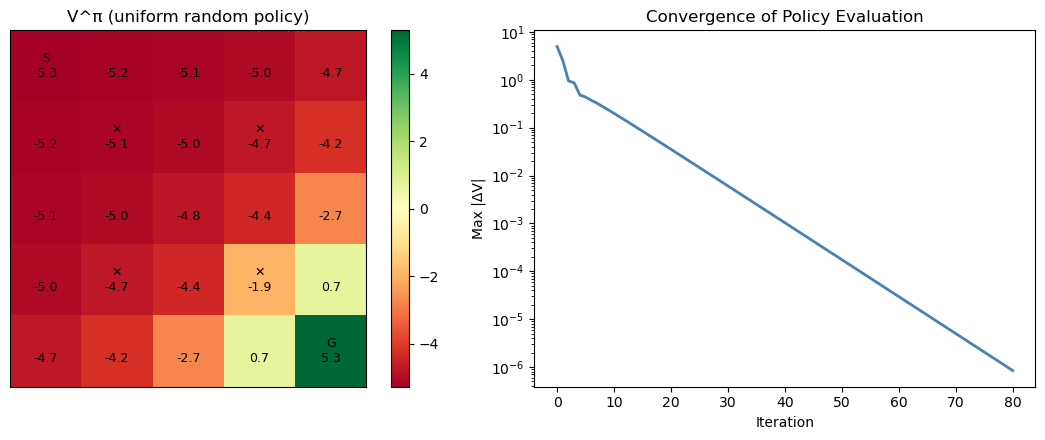

In [16]:
# Visualise final value function
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Heatmap
im = axes[0].imshow(V.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=axes[0])
for r in range(5):
    for c in range(5):
        label = ''
        if (r,c)==env.goal: label='G'
        elif (r,c)==env.start: label='S'
        elif (r,c) in env.pits: label='✕'
        axes[0].text(c, r, f'{label}\n{V[r*5+c]:.1f}', ha='center', va='center', fontsize=9)
axes[0].set_title('V^π (uniform random policy)'); axes[0].set_xticks([]); axes[0].set_yticks([])

# Convergence curve
max_delta = [np.max(np.abs(history[i+1]-history[i])) for i in range(len(history)-1)]
axes[1].semilogy(max_delta, color='steelblue', linewidth=2)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Max |ΔV|')
axes[1].set_title('Convergence of Policy Evaluation')
plt.tight_layout(); plt.show()

## ✅ Exercises
1. Try γ=0.5, γ=0.9, γ=0.999. How does the value function shape change?
2. Create a policy that always moves RIGHT. Evaluate it. What happens to states on the rightmost column?
3. **Challenge**: implement **in-place** policy evaluation (update V[s] immediately instead of V_new). Does it converge faster?

Ans1) Result -- 	value	is	nearly	flat	and	slightly	negative	except
right	next	to	the	goal/pits	—	future	rewards	are	invisible	beyond	2–3
steps,	so	the	“gradient”	toward	the	goal	vanishes.	-	γ=0.9:	a	visible
slope	toward	the	goal	emerges;	pits	create	local	dips.	-	γ=0.999:	the
whole	grid	is	dominated	by	long-run	outcomes	—	under	a	random
policy	that	mostly	means	eventually	falling	into	a	pit,	so	values	get more negative	overall	while	the	relative	goal-gradient	sharpen

Converged in 18 iterations (Δ=5.39e-07)
Converged in 53 iterations (Δ=8.62e-07)
Converged in 85 iterations (Δ=8.87e-07)


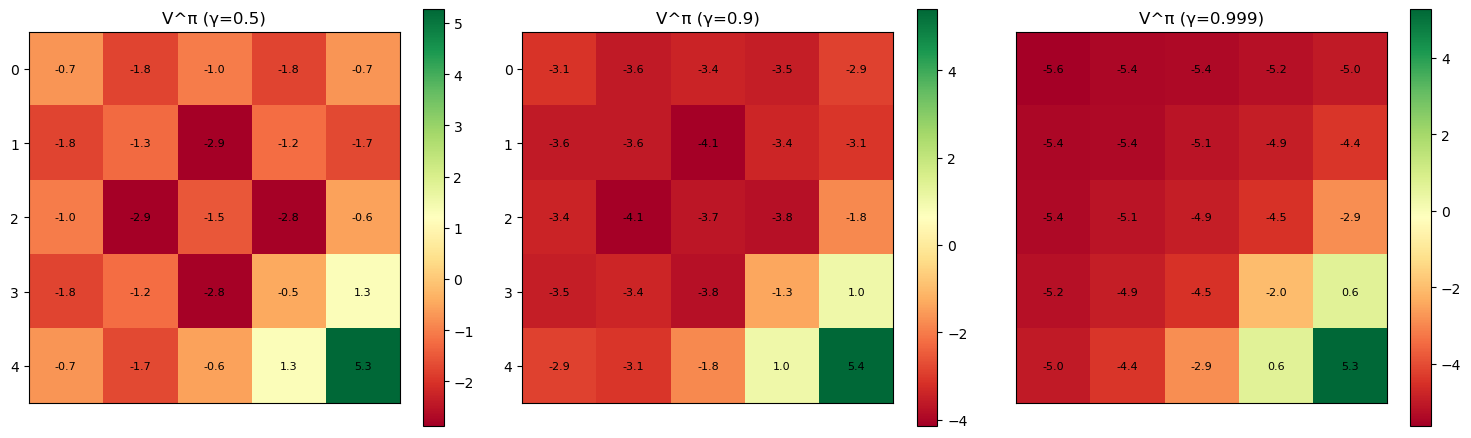

In [17]:
fig,	axes	=	plt.subplots(1,	3,	figsize=(15,	4.5))
for	ax,	g	in	zip(axes,	[0.5,	0.9,	0.999]):
				Vg,	_	=	policy_evaluation(env,	uniform_policy,	gamma=g)
				im	=	ax.imshow(Vg.reshape(5,	5),	cmap='RdYlGn')
				plt.colorbar(im,	ax=ax)
				for	s	in	range(25):
								r,	c	=	divmod(s,	5)
								ax.text(c,	r,	f'{Vg[s]:.1f}',	ha='center',	va='center',	
fontsize=8)
				ax.set_title(f'V^π (γ={g})');	ax.set_xticks([]);	
ax.set_yticks([])
plt.tight_layout();	plt.show()


Ans 2) Obs - a	deterministic	policy’s	value	function	exposes	exactly	where
it	gets	stuck.

In [18]:
right_policy	=	np.zeros((n_s,	n_a))
right_policy[:,	3]	=	1.0								#	action	3	=	RIGHT
V_right,	_	=	policy_evaluation(env,	right_policy)
env_render	=	V_right.reshape(5,	5)
print(np.round(env_render,	2))
print("\nRightmost	column	values:",	np.round(V_right[[4, 9,	14,	19]],	2))
print("Theoretical	for	a	stuck	state:	-0.1/(1-0.99)	=",	
round(-0.1/(1-0.99),	2))

[[-10.   -10.   -10.   -10.   -10.  ]
 [ -5.    -5.05  -5.   -10.   -10.  ]
 [-10.   -10.   -10.   -10.   -10.  ]
 [ -5.    -5.05  -5.   -10.   -10.  ]
 [  9.41   9.6    9.8   10.    10.  ]]

Rightmost	column	values: [-10. -10. -10. -10.]
Theoretical	for	a	stuck	state:	-0.1/(1-0.99)	= -10.0


Ans 3) Note - Reason:	within	a	single	sweep,	later
states	already	use	the	freshly	updated	values	of	earlier	states,	so
information	propagates	faster.	Both	converge	to	the	same	V^π.

In [19]:
def	policy_evaluation_inplace(env,	policy,	gamma=0.99,	theta=1e-6,	max_iter=1000):
				V	=	np.zeros(env.n_states())
				for	iteration	in	range(max_iter):
								delta	=	0.0
								for	s	in	range(env.n_states()):
												v	=	0.0
												for	a	in	range(env.n_actions()):
																for	prob,	ns,	reward,	done	in	env.transitions(s,	a):
																				v	+=	policy[s,	a]	*	prob	*	(reward	+	(0	if	done	else	gamma	*	V[ns]))
												delta	=	max(delta,	abs(v	-	V[s]))
												V[s]	=	v																					#	<--	immediate	update,	no	V_new
								if	delta	<	theta:
												return	V,	iteration	+	1
				return	V,	max_iter
V_sync,	hist	=	policy_evaluation(env,	uniform_policy)
V_ip,	n_ip			=	policy_evaluation_inplace(env,	uniform_policy)
print(f"Two-array	sweeps:	{len(hist)-1}")
print(f"In-place	sweeps:		{n_ip}")
print(f"Same	answer:	{np.allclose(V_sync,	V_ip,	atol=1e-4)}")


Converged in 81 iterations (Δ=8.45e-07)
Two-array	sweeps:	81
In-place	sweeps:		60
Same	answer:	True
